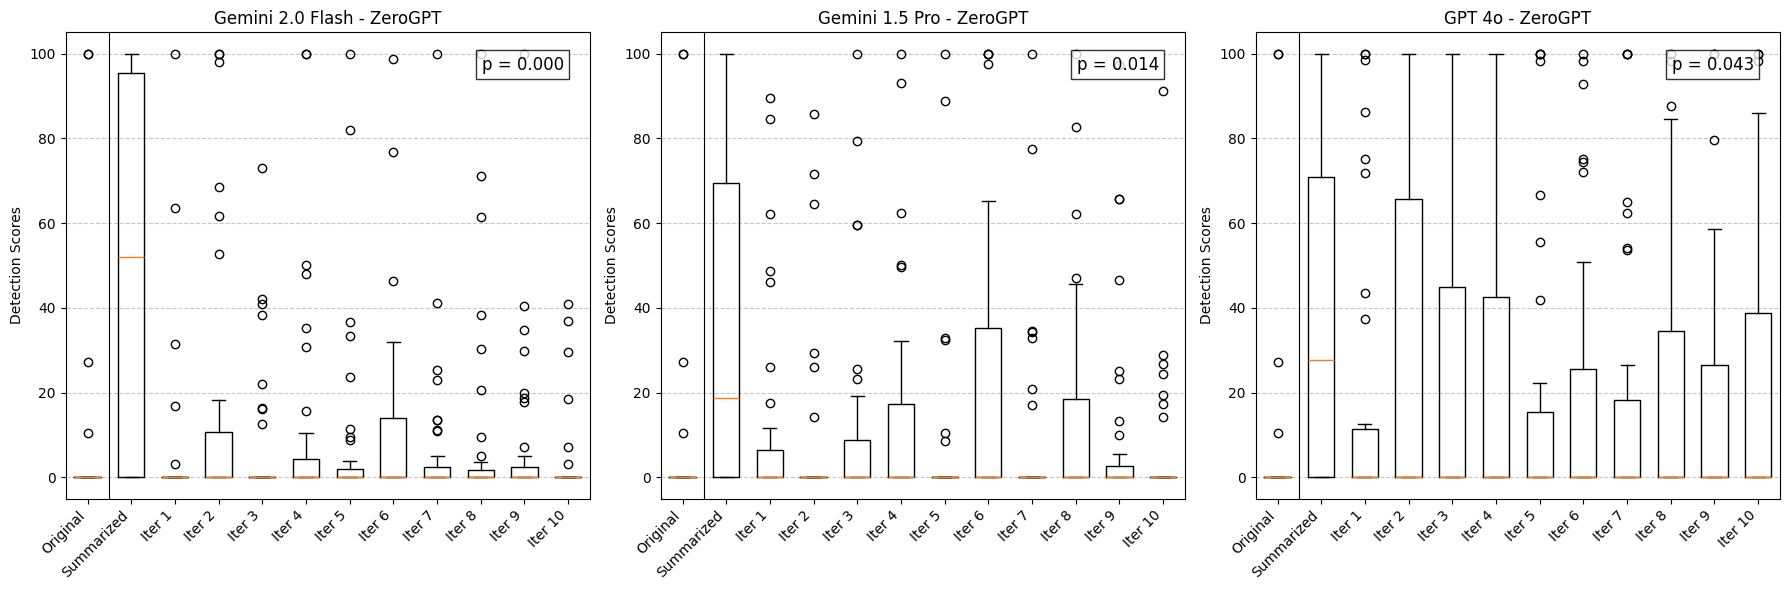

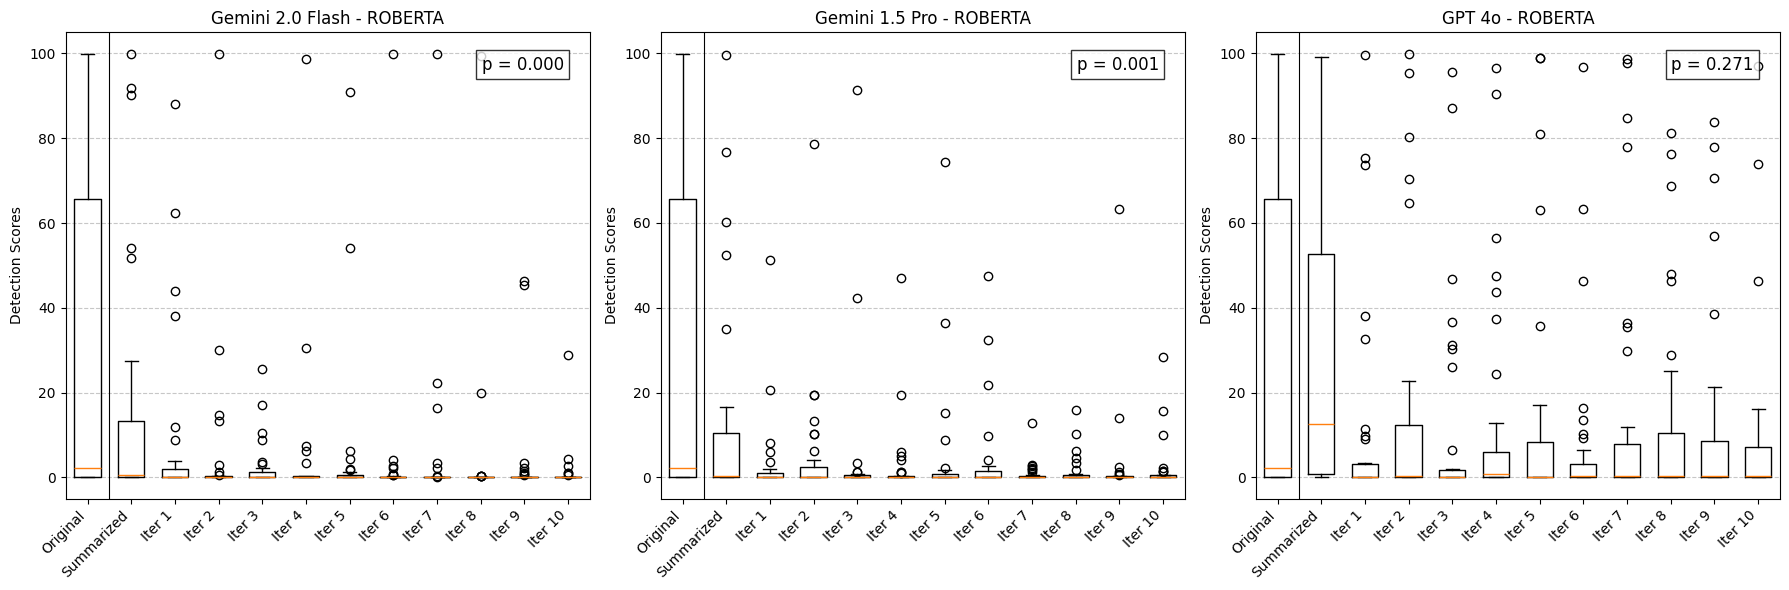

In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Define the file paths
file_paths = [
    "3_checkingHumanity/data/gemini2FlashIterationsWithScores.json",
    "3_checkingHumanity/data/gemini15ProIterationsWithScores.json",
    "3_checkingHumanity/data/GPT4oIterationsWithScores.json"
]

def process_file(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    iterations_data = {}
    original_scores = {"ZeroGPT": [], "ROBERTA": []}
    summarized_scores = {"ZeroGPT": [], "ROBERTA": []}
    
    def safe_append(score_list, value):
        if value is not None:
            score_list.append(value)
    
    for entry in data:
        safe_append(original_scores["ZeroGPT"], entry["original_text_metrics"]["detection_scores"].get("zerogpt"))
        safe_append(original_scores["ROBERTA"], entry["original_text_metrics"]["detection_scores"].get("roberta"))
        
        safe_append(summarized_scores["ZeroGPT"], entry["summarized_text_metrics"]["detection_scores"].get("zerogpt"))
        safe_append(summarized_scores["ROBERTA"], entry["summarized_text_metrics"]["detection_scores"].get("roberta"))
        
        for iteration in entry["iterations"]:
            iteration_num = iteration["iteration_number"]
            if iteration_num not in iterations_data:
                iterations_data[iteration_num] = {"ZeroGPT": [], "ROBERTA": []}
            safe_append(iterations_data[iteration_num]["ZeroGPT"], iteration["detection_scores"].get("zerogpt"))
            safe_append(iterations_data[iteration_num]["ROBERTA"], iteration["detection_scores"].get("roberta"))
    
    return original_scores, summarized_scores, iterations_data

datasets = [process_file(file_path) for file_path in file_paths]

def plot_scores(fig, axes, method, datasets, titles):
    for i, (original_scores, summarized_scores, iterations_data) in enumerate(datasets):
        ax = axes[i]
        positions = [1, 2]
        labels = ["Original", "Summarized"]
        data_to_plot = [original_scores[method], summarized_scores[method]]
        iteration_labels = []  # Labels for Kendall's tau test (excluding 'Original')
        pos_index = 3
        
        for iteration_num, scores in sorted(iterations_data.items()):
            positions.append(pos_index)
            labels.append(f"Iter {iteration_num}")
            data_to_plot.append(scores[method])
            iteration_labels.extend([pos_index] * len(scores[method]))  # Track positions for Kendall's tau
            pos_index += 1
        
        ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=False)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("Detection Scores")
        ax.set_title(f"{titles[i]} - {method}")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.axvline(x=1.5, color='black', linestyle='-', linewidth=0.8)
        
        # Perform Kendall's Tau test excluding the first 'Original' x-tick
        scores_flat = [score for group in data_to_plot[1:] for score in group]  # Exclude Original
        iter_labels_flat = [2] * len(data_to_plot[1]) + iteration_labels  # Start from Summarized (2)
        
        if len(set(iter_labels_flat)) > 1:
            tau, p_value = stats.kendalltau(iter_labels_flat, scores_flat)
            ax.text(0.95, 0.95, f"p = {p_value:.3f}", transform=ax.transAxes, 
                    verticalalignment='top', horizontalalignment='right', fontsize=12, 
                    bbox=dict(facecolor='white', alpha=0.8))

# Create figure for ZeroGPT
titles = ["Gemini 2.0 Flash", "Gemini 1.5 Pro", "GPT 4o"]
fig1, axes1 = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharex=True)
plot_scores(fig1, axes1, "ZeroGPT", datasets, titles)
plt.tight_layout()
plt.show()

# Create figure for ROBERTA
fig2, axes2 = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharex=True)
plot_scores(fig2, axes2, "ROBERTA", datasets, titles)
plt.tight_layout()
plt.show()


In [6]:
from genson import SchemaBuilder
import json

file_path = "3_checkingHumanity/data/gemini2FlashIterationsWithScores.json"

with open(file_path, "r") as f:
    data = json.load(f)

# Generate schema
builder = SchemaBuilder()
builder.add_object(data)

print(json.dumps(builder.to_schema(), indent=4))


{
    "$schema": "http://json-schema.org/schema#",
    "type": "array",
    "items": {
        "type": "object",
        "properties": {
            "id": {
                "type": "integer"
            },
            "original_text": {
                "type": "string"
            },
            "summarized_text": {
                "type": "string"
            },
            "iterations": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "iteration_number": {
                            "type": "integer"
                        },
                        "rewritten_text": {
                            "type": "string"
                        },
                        "detection_scores": {
                            "type": "object",
                            "properties": {
                                "zerogpt": {
                                    "type": [
          